# ДЗ по "Библиотеки Python для Data Science: Numpy, Matplotlib, Scikit-learn"
##  Курсовой проект.Задание для курсового проекта:

Метрика:
R2 - коэффициент детерминации (sklearn.metrics.r2_score)

Сдача проекта:
1. Прислать в раздел Задания Урока 10 ("Вебинар. Консультация по итоговому проекту")
ссылку на ноутбук в github или public kaggle notebook.
2. Необходимо получить R2 > 0.6.

Примечание:
Все файлы csv должны содержать названия полей (header - то есть "шапку"),
разделитель - запятая. В файлах не должны содержаться индексы из датафрейма.
____________
Рекомендации для файла с кодом (ipynb):
1. Файл должен содержать заголовки и комментарии
2. Повторяющиеся операции лучше оформлять в виде функций
3. По возможности добавлять графики, описывающие данные (около 3-5)
4. Добавлять только лучшую модель, то есть не включать в код все варианты решения проекта
5. Скрипт проекта должен отрабатывать от начала и до конца (от загрузки данных до выгрузки предсказаний)
6. Весь проект должен быть в одном скрипте (файл ipynb).
7. При использовании статистик (среднее, медиана и т.д.) в качестве признаков,
лучше считать их на трейне, и потом на валидационных и тестовых данных не считать 
статистики заново, а брать их с трейна.
8. Проект должен полностью отрабатывать за разумное время (не больше 10 минут),
поэтому в финальный вариант лучше не включать GridSearch с перебором 
большого количества сочетаний параметров.).

### Содержание:
- [Установка необходимых пакетов, если они не установлены](#inst)
- [Импорт библиотек](#libr)
- [Загрузка датасета](#load_data)
  - [Описание данных](#description)
- [Разведочный анализ даных (EDA)](#eda)
  - [Посмотрим типы данных](#dtypes)
  - [Посмотрим пропуски данных](#pass)
  - [Посмотри статистику по датафрейму](#statistics)
  - [Визуализируем данные](#visual)
    - [Выделим численные признаки от остальных](#num_and_char)
    - [Создадим словарь признаков и их русский перевод](#translate)
    - [Визуализируем распределение числовых признаков](#num_visual)
    - [Визуализируем распределение целевой переменной](#target_visual)
    - [Визуализируем распределение строковых признаков](#char_visual)

### Установка пакетов если они не установлены <a class='anchor' id='inst'>

In [1]:
# Для кождого проекта я использую новое окружение, 
# думаю это помогает избежать ошибок связанных с версиями пакетов
# !pip install pandas
# !pip install matplotlib
# !pip install seaborn
# !pip install numpy
# !pip install scikit-learn

### Импортируем библиотеки <a class='anchor' id='libr'>

In [2]:
# Импортируем необходимые библиотеки
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
# Следующая магическая команда Jupyter Notebook нужна для того, чтобы графики
# отображались прямо в ноутбуке, а не в отдельном окне
%matplotlib inline

# Настройка более четкого отображения графиков
%config InlineBackend.figure_format = 'svg'

# Модуль для зазбиения выборки на тренировочнию и тестовую
from sklearn.model_selection import train_test_split

# Стандартизация
from sklearn.preprocessing import StandardScaler

# Уберем warnings
import warnings
warnings.filterwarnings('ignore')

# Настройка формата вывода чисел float
pd.set_option('display.float_format', '{:.2f}'.format)

### Загружаем данные <a class='anchor' id='load_data'>

Описание данных <a class='anchor' id='description'>
- **Id** - идентификационный номер квартиры;
- **DistrictId** - идентификационный номер района;
- **Rooms** - количество комнат;
- **Square** - площадь;
- **LifeSquare** - жилая площадь;
- **KitchenSquare** - площадь кухни;
- **Floor** - этаж;
- **HouseFloor** - количество этажей в доме;
- **HouseYear** - год постройки дома;
- **Ecology_1**, **Ecology_2**, **Ecology_3** - экологические показатели месности;
- **Social_1**, **Social_2**, **Social_3** - социальные показатели месности;
- **Healtcare_1**, **Heltcare_2** - показатели месности, связанные с охраной здоровья;
- **Shops_1**, **Shops_2** - показатели связанные с наличием магазинов, торговых центров;
- **Price** - цена квартиры.

In [3]:
# Расположение данных
TEST_DATA = './CSV/test.csv'
TRAIN_DATA = './CSV/train.csv'

In [4]:
# Читаем csv файл тренировочных данных
df_train_data = pd.read_csv(TRAIN_DATA, engine='python', on_bad_lines='skip')
df_train_data.head()

,Id,DistrictId,Rooms,Square,LifeSquare,KitchenSquare,Floor,HouseFloor,HouseYear,Ecology_1,Ecology_2,Ecology_3,Social_1,Social_2,Social_3,Healthcare_1,Helthcare_2,Shops_1,Shops_2,Price
0,14038,35,2.00,47.98,29.44,6.00,7,9.00,1969,0.09,B,B,33,7976,5,NaN,0,11,B,184966.93
1,15053,41,3.00,65.68,40.05,8.00,7,9.00,1978,0.00,B,B,46,10309,1,240.00,1,16,B,300009.45
2,4765,53,2.00,44.95,29.20,0.00,8,12.00,1968,0.05,B,B,34,7759,0,229.00,1,3,B,220925.91
3,5809,58,2.00,53.35,52.73,9.00,8,17.00,1977,0.44,B,B,23,5735,3,1084.00,0,5,B,175616.23
4,10783,99,1.00,39.65,23.78,7.00,11,12.00,1976,0.01,B,B,35,5776,1,2078.00,2,4,B,150226.53


In [5]:
# Посмотрим размерность тренировочных данных
df_train_data.shape

(10000, 20)

In [6]:
# Читаем csv файл тестовых данных
df_test_data = pd.read_csv(TEST_DATA, engine='python', on_bad_lines='skip')
df_test_data.head()

,Id,DistrictId,Rooms,Square,LifeSquare,KitchenSquare,Floor,HouseFloor,HouseYear,Ecology_1,Ecology_2,Ecology_3,Social_1,Social_2,Social_3,Healthcare_1,Helthcare_2,Shops_1,Shops_2
0,725,58,2.00,49.88,33.43,6.00,6,14.00,1972,0.31,B,B,11,2748,1,NaN,0,0,B
1,15856,74,2.00,69.26,NaN,1.00,6,1.00,1977,0.08,B,B,6,1437,3,NaN,0,2,B
2,5480,190,1.00,13.60,15.95,12.00,2,5.00,1909,0.00,B,B,30,7538,87,4702.00,5,5,B
3,15664,47,2.00,73.05,51.94,9.00,22,22.00,2007,0.10,B,B,23,4583,3,NaN,3,3,B
4,14275,27,1.00,47.53,43.39,1.00,17,17.00,2017,0.07,B,B,2,629,1,NaN,0,0,A


In [7]:
# Посмотрим размерность тестовых данных
df_test_data.shape

(5000, 19)

**Вывод:** данные загрузились, всё супер. В тесте как и полагается отсутствует столбец `price`, который нам нужно предсказать.В `train` 10_000, а в `test` 5_000 записей.

### Разведочный анализ даных (EDA) <a class='anchor' id='eda'>

#### Посмотрим типы данных <a class='anchor' id='dtypes'>

In [8]:
df_train_data.dtypes

Id                 int64
DistrictId         int64
Rooms            float64
Square           float64
LifeSquare       float64
KitchenSquare    float64
Floor              int64
HouseFloor       float64
HouseYear          int64
Ecology_1        float64
Ecology_2         object
Ecology_3         object
Social_1           int64
Social_2           int64
Social_3           int64
Healthcare_1     float64
Helthcare_2        int64
Shops_1            int64
Shops_2           object
Price            float64
dtype: object

**Вывод:** надо будет перевести некоторые текстовые фичи в цифру.

#### Посмотрим пропуски данных <a class='anchor' id='pass'>

In [9]:
# Настроим pd, чтобы выводились все строки 
pd.set_option('display.max_rows', None)
# Проверка того, в каких столбцах отсутствуют значения
print(df_train_data.isnull().sum(axis=0))
# Сбросим настройки вывода строк
pd.reset_option('display.max_rows')

Id                  0
DistrictId          0
Rooms               0
Square              0
LifeSquare       2113
KitchenSquare       0
Floor               0
HouseFloor          0
HouseYear           0
Ecology_1           0
Ecology_2           0
Ecology_3           0
Social_1            0
Social_2            0
Social_3            0
Healthcare_1     4798
Helthcare_2         0
Shops_1             0
Shops_2             0
Price               0
dtype: int64


**Вывод:** Фича `Healthcare_1` не информативна, её надо будет удалить. В фиче `LifeSquare` заполним пропускки.

#### Посмотри статистику по датафрейму <a class='anchor' id='statistics'>

In [10]:
df_train_data.describe()

,Id,DistrictId,Rooms,Square,LifeSquare,KitchenSquare,Floor,HouseFloor,HouseYear,Ecology_1,Social_1,Social_2,Social_3,Healthcare_1,Helthcare_2,Shops_1,Price
count,10000.00,10000.00,10000.00,10000.00,7887.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,5202.00,10000.00,10000.00,10000.00
mean,8383.41,50.40,1.89,56.32,37.20,6.27,8.53,12.61,3990.17,0.12,24.69,5352.16,8.04,1142.90,1.32,4.23,214138.86
std,4859.02,43.59,0.84,21.06,86.24,28.56,5.24,6.78,200500.26,0.12,17.53,4006.80,23.83,1021.52,1.49,4.81,92872.29
min,0.00,0.00,0.00,1.14,0.37,0.00,1.00,0.00,1910.00,0.00,0.00,168.00,0.00,0.00,0.00,0.00,59174.78
25%,4169.50,20.00,1.00,41.77,22.77,1.00,4.00,9.00,1974.00,0.02,6.00,1564.00,0.00,350.00,0.00,1.00,153872.63
50%,8394.50,36.00,2.00,52.51,32.78,6.00,7.00,13.00,1977.00,0.08,25.00,5285.00,2.00,900.00,1.00,3.00,192269.64
75%,12592.50,75.00,2.00,65.90,45.13,9.00,12.00,17.00,2001.00,0.20,36.00,7227.00,5.00,1548.00,2.00,6.00,249135.46
max,16798.00,209.00,19.00,641.07,7480.59,2014.00,42.00,117.00,20052011.00,0.52,74.00,19083.00,141.00,4849.00,6.00,23.00,633233.47


#### Визуализируем данные <a class='anchor' id='visual'>

##### Выделим численные признаки от остальных <a class='anchor' id='num_and_char'>

In [11]:
num_cols = []
str_cols = []

cols_and_type = df_train_data.dtypes.to_dict()

for col in cols_and_type:
    if cols_and_type[col] in ('int64', 'float64'):
        num_cols.append(col)
    else: 
        str_cols.append(col)
        
print(num_cols)

['Id', 'DistrictId', 'Rooms', 'Square', 'LifeSquare', 'KitchenSquare', 'Floor', 'HouseFloor', 'HouseYear', 'Ecology_1', 'Social_1', 'Social_2', 'Social_3', 'Healthcare_1', 'Helthcare_2', 'Shops_1', 'Price']


In [12]:
# Словарь название столбца и тип данных
cols_and_type

{'Id': dtype('int64'),
 'DistrictId': dtype('int64'),
 'Rooms': dtype('float64'),
 'Square': dtype('float64'),
 'LifeSquare': dtype('float64'),
 'KitchenSquare': dtype('float64'),
 'Floor': dtype('int64'),
 'HouseFloor': dtype('float64'),
 'HouseYear': dtype('int64'),
 'Ecology_1': dtype('float64'),
 'Ecology_2': dtype('O'),
 'Ecology_3': dtype('O'),
 'Social_1': dtype('int64'),
 'Social_2': dtype('int64'),
 'Social_3': dtype('int64'),
 'Healthcare_1': dtype('float64'),
 'Helthcare_2': dtype('int64'),
 'Shops_1': dtype('int64'),
 'Shops_2': dtype('O'),
 'Price': dtype('float64')}

##### Создадим словарь признаков и их русский перевод <a class='anchor' id='translate'>

In [18]:
# Словарь признаков и их русский перевод
translate_col = {
    'Id': 'идентификационный номер квартиры',
    'DistrictId': 'идентификационный номер района',
    'Rooms': 'количество комнат',
    'Square': 'площадь',
    'LifeSquare': 'жилая площадь',
    'KitchenSquare': 'площадь кухни',
    'Floor': 'этаж',
    'HouseFloor': 'количество этажей в доме',
    'HouseYear': 'год постройки дома',
    'Ecology_1': 'экологические показатели месности 1',
    'Ecology_2': 'экологические показатели месности 2',
    'Ecology_3': 'экологические показатели месности 3',
    'Social_1': 'социальные показатели месности 1',
    'Social_2': 'социальные показатели месности 2',
    'Social_3': 'социальные показатели месности 3',
    'Healthcare_1': 'показатели месности,\n связанные с охраной здоровья 1',
    'Helthcare_2': 'показатели месности,\n связанные с охраной здоровья 2',
    'Shops_1': 'показатели связанные с наличием\n магазинов, торговых центров 1',
    'Shops_2': 'показатели связанные с наличием\n магазинов, торговых центров 2',
    'Price': 'цена квартиры'
}

In [29]:
def visualization_numerical_characteristics():
    '''
    Визуализация цифровых признаков (так сделал, чтобы код в одном месте находился).
    '''
    plt.figure(figsize=[11, 13])

    # Общий заголовок для всех графиков
    plt.suptitle('Распределение числовых признаков', 
                  y=1.005, 
                  fontsize=19, 
                  fontweight='bold')

    for i, col in enumerate(num_cols):
        plt.subplot(6, 3, i+1)
        # Заголовок для графика
        plt.title(f'\n{col} \n({translate_col[col]})', fontsize=10)
        # Задаём размер шривта и угол поворота текста для осей X и Y
        plt.xticks(fontsize=8)
        plt.yticks(fontsize=8)
        # Делаем размер шрифта по Y=5, не уберая название оси
        plt.ylabel('', fontsize=5)
        # Отрисовываем гистограмму
        plt.hist(df_train_data[col])

    # Автоматически уместить все элементы на полотне    
    plt.tight_layout()

    # Вывести графики на экран
    plt.show()

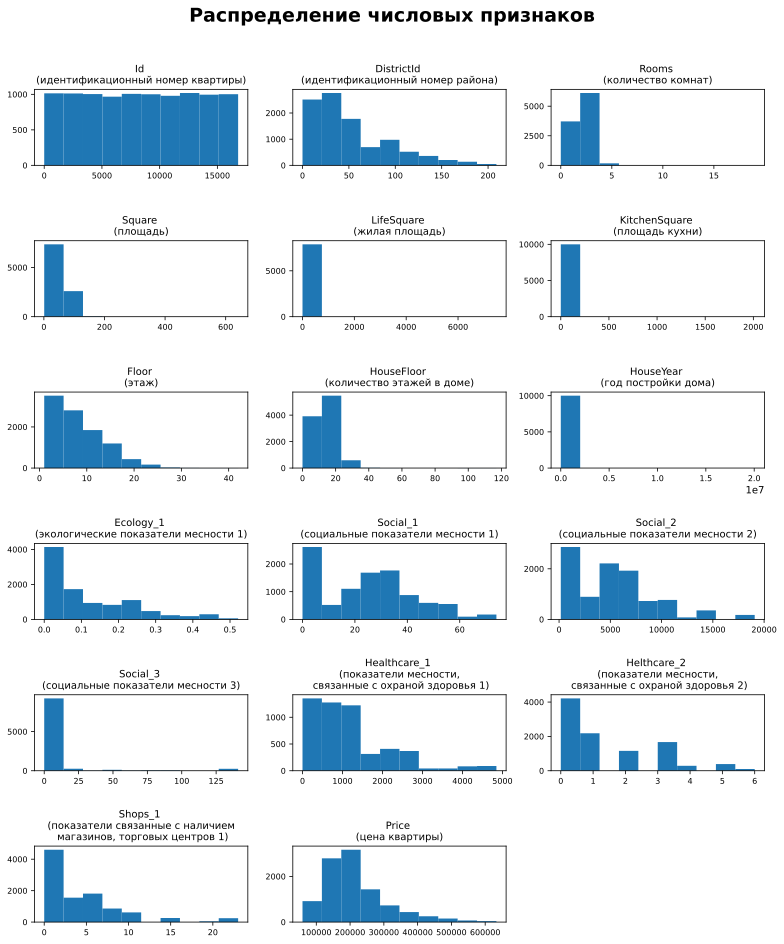

In [30]:
visualization_numerical_characteristics()

##### Визуализируем распределение строковых признаков

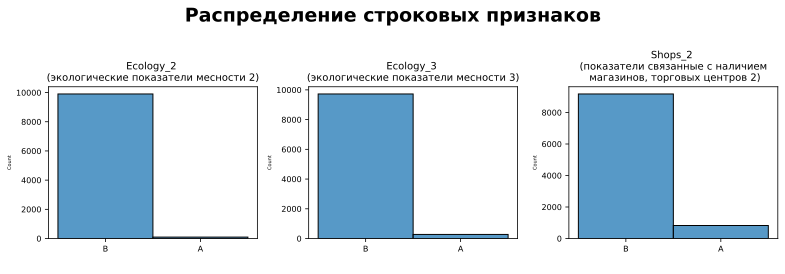

In [42]:
# Задаём размеры полотна [ширина, длина]
plt.figure(figsize=[11, 6])

# Общий заголовок для всех графиков
plt.suptitle('Распределение строковых признаков', 
              y=1.005, 
              fontsize=19, 
              fontweight='bold')
index_plt = 0
# Добавляем графики на полотно (3 шт. в одном ряду)
for col in str_cols:
    plt.subplot(2, 3, index_plt+1)
    # Заголовок для графика
    plt.title(f'{col} \n({translate_col[col]})', fontsize=10)
    # Задаём размер шривта и угол поворота текста для осей X и Y
    plt.xticks(fontsize=8)
    plt.yticks(fontsize=8)
    # Убираем подпись оси X
    plt.xlabel(' ')
    # Делаем размер шрифта по Y=5, не уберая название оси
    plt.ylabel('', fontsize=5)
    # Отрисовываем гистограмму
    sns.histplot(df_train_data[col])
    index_plt += 1

# Автоматически уместить все элементы на полотне    
plt.tight_layout()

# Вывести графики на экран
plt.show()

array([[<Axes: title={'center': 'Id'}>,
        <Axes: title={'center': 'DistrictId'}>,
        <Axes: title={'center': 'Rooms'}>,
        <Axes: title={'center': 'Square'}>],
       [<Axes: title={'center': 'LifeSquare'}>,
        <Axes: title={'center': 'KitchenSquare'}>,
        <Axes: title={'center': 'Floor'}>,
        <Axes: title={'center': 'HouseFloor'}>],
       [<Axes: title={'center': 'HouseYear'}>,
        <Axes: title={'center': 'Ecology_1'}>,
        <Axes: title={'center': 'Social_1'}>,
        <Axes: title={'center': 'Social_2'}>],
       [<Axes: title={'center': 'Social_3'}>,
        <Axes: title={'center': 'Healthcare_1'}>,
        <Axes: title={'center': 'Helthcare_2'}>,
        <Axes: title={'center': 'Shops_1'}>],
       [<Axes: title={'center': 'Price'}>, <Axes: >, <Axes: >, <Axes: >]],
      dtype=object)

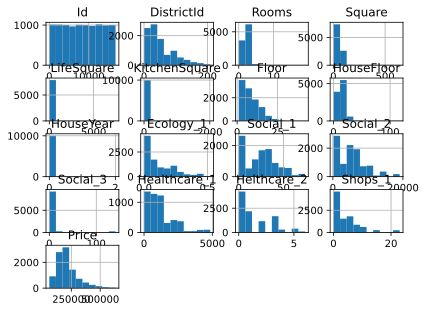

In [17]:
df_train_data.hist()